# Assignment 3: NLP Web-based Data Application
## Milestone I — Task 2 & 3
#### Student Name: XXXX XXXX
#### Student ID: 000000

**Environment:** Python 3 and Jupyter Notebook

**Libraries used:**
- `pandas` — data loading and manipulation
- `numpy` — numerical computations and vector operations
- `gensim` — training Word2Vec embeddings
- `scikit-learn` — TF-IDF, classifiers, cross-validation, metrics
- `scipy` — sparse matrix handling
- `matplotlib`, `seaborn` — visualisation

## Introduction
This notebook covers Task 2 and Task 3 of Milestone I. In **Task 2**, we generate three document-level feature representations from the preprocessed cosmetics review data produced in Task 1:
1. **Bag-of-Words (Count Vectors)** — sparse term-frequency vectors using the Task 1 vocabulary.
2. **Unweighted Word2Vec Embeddings** — mean of Word2Vec word vectors per review.
3. **TF-IDF Weighted Word2Vec Embeddings** — TF-IDF weighted average of Word2Vec vectors per review.

In **Task 3**, we train classifiers to predict purchase behaviour (`is_a_buyer`) using 5-fold cross-validation. We report accuracy, precision, recall, and F1-score, compare language models (Q1), and assess whether adding extra features improves accuracy (Q2).

## Importing Libraries

In [1]:
!pip install gensim
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.sparse import csr_matrix, hstack as sparse_hstack
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.9 MB/s eta 0:00:00
All libraries imported successfully.


## Loading Data

In [2]:
# Load the preprocessed dataset from Task 1
df = pd.read_csv('processed.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nis_a_buyer distribution:')
print(df['is_a_buyer'].value_counts())
df.head(3)

Dataset shape: (61284, 15)
Columns: ['product_id', 'brand_name', 'review_id', 'review_title', 'review_text', 'author', 'review_date', 'review_rating', 'is_a_buyer', 'product_title', 'price', 'avg_product_rating', 'product_rating_count', 'product_tags', 'product_url']

is_a_buyer distribution:
is_a_buyer
True     48222
False    13062
Name: count, dtype: int64


,product_id,brand_name,review_id,review_title,review_text,author,review_date,review_rating,is_a_buyer,product_title,price,avg_product_rating,product_rating_count,product_tags,product_url
0,781070,Olay,16752142,Worth buying 50g one,works claims difference day olay cleanser results,Ashton Dsouza,23/01/2021 15:17,5.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
1,781070,Olay,14682550,Best cream to start ur day,claims thing smoothens ur makes soft,Amrit Neelam,07/09/2020 15:30,5.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...
2,781070,Olay,15618995,perfect for summers dry for winters,months combination oily greasy absorbs quickly...,Sanchi Gupta,13/11/2020 12:24,4.0,True,Olay Ultra Lightweight Moisturiser: Luminous W...,1599,4.1,43,NaN,https://www.nykaa.com/olay-ultra-lightweight-m...


In [3]:
# Load vocabulary from Task 1: word -> index mapping
vocab = OrderedDict()
with open('vocab.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if ':' in line:
            word, idx = line.rsplit(':', 1)
            vocab[word] = int(idx)

vocab_size = len(vocab)
print(f'Vocabulary size: {vocab_size}')
print(f'Sample entries: {list(vocab.items())[:5]}')

Vocabulary size: 8054
Sample entries: [('aa', 0), ('aback', 1), ('abd', 2), ('abh', 3), ('ability', 4)]


In [4]:
# Prepare review texts and tokenise (reviews already preprocessed in Task 1)
df['review_text'] = df['review_text'].fillna('')
review_texts = df['review_text'].tolist()
tokenised_reviews = [text.split() for text in review_texts]

# Target variable: is_a_buyer as 0 / 1
labels = df['is_a_buyer'].astype(int).values

print(f'Total reviews : {len(tokenised_reviews)}')
print(f'Buyers (1)    : {labels.sum()}')
print(f'Non-buyers (0): {(labels == 0).sum()}')

Total reviews : 61284
Buyers (1)    : 48222
Non-buyers (0): 13062


---
## Task 2. Generating Feature Representations

### 2.1 Bag-of-Words (Count Vectors)
For each review we count how many times each vocabulary word appears, producing a sparse vector of length equal to the vocabulary size.

In [5]:
count_vectors_data = []   # list of {word_index: frequency} for file output
rows, cols, vals = [], [], []

for i, tokens in enumerate(tokenised_reviews):
   # For each review, build a word count dictionary
    word_counts = {}
    for token in tokens:
      # Only count words that exist in the Task 1 vocabulary
        if token in vocab: # Get the word index from vocab.txt
            idx = vocab[token]
            # Increment the frequency count for this word index
            word_counts[idx] = word_counts.get(idx, 0) + 1

    # Store the count dictionary for this review
    count_vectors_data.append(word_counts)

    # Populate sparse matrix data: add (row, col, value) triplets
    for idx, freq in word_counts.items():
        rows.append(i);# row = review index
        cols.append(idx);  # col = word index from vocab
        vals.append(freq) # value = frequency count
# Build sparse CSR matrix: (num_reviews × vocab_size)
# Each row is a review, each column is a word from the vocabulary
# Non-zero values represent word frequencies
bow_matrix = csr_matrix((vals, (rows, cols)), shape=(len(tokenised_reviews), vocab_size))

# Clean up temporary lists to free memory
del rows, cols, vals; gc.collect()

print(f'Sparse BoW matrix shape: {bow_matrix.shape}')
print(f'Sample review 0: {dict(list(count_vectors_data[0].items())[:5])} ...')

Sparse BoW matrix shape: (61284, 8054)
Sample review 0: {7940: 1, 1140: 1, 1873: 1, 1706: 1, 4828: 1} ...


### 2.2 Training Word2Vec

 This Word2Vec model is used by both Task 2.3 and Task 2.4
  
  - Task 2.3 uses it to compute unweighted embeddings (simple averaging)
   - Task 2.4 uses it to compute TF-IDF weighted embeddings

Train a Word2Vec model on the preprocessed review corpus
**Word2Vec** learns semantic relationships between words by predicting context

In [6]:
print('Training Word2Vec...')
w2v_model = Word2Vec(
    sentences=tokenised_reviews,  # Input: list of tokenized reviews
    vector_size=100,              # Output: 100-dimensional word vectors
    window=5,                     # Context window: 5 words left + 5 words right
    min_count=1,                  # Include all words (vocab already filtered in Task 1)
    workers=4,                    # Use 4 CPU threads for faster training
    seed=42,                      # Random seed for reproducibility
    epochs=10                     # Train for 10 passes over the entire corpus
)
# Extract embedding dimension for later use
embedding_dim = w2v_model.wv.vector_size
print(f'Done: {len(w2v_model.wv)} words, {embedding_dim} dimensions.')
# If training worked well, similar words should be related to skincare
try:
    print(f'Words similar to "moisturiser": {w2v_model.wv.most_similar("moisturiser", topn=3)}')
except:
    # Word might not be in vocabulary, or model too small
    pass

Training Word2Vec...
Done: 8054 words, 100 dimensions.
Words similar to "moisturiser": [('moisturizer', 0.907575786113739), ('mattifying', 0.7995242476463318), ('lotion', 0.7917590141296387)]


### 2.3 Unweighted Word Embedding Vectors

In [7]:
def get_unweighted_embedding(tokens, model, dim):
    """Mean of Word2Vec vectors for all tokens in the review."""
    # Get Word2Vec vectors for all tokens that exist in the model vocabulary
    vectors = [model.wv[t] for t in tokens if t in model.wv]

    # If the review has at least one valid word vector, return the mean
    # Otherwise return a zero vector (review has no vocabulary words)
    return np.mean(vectors, axis=0) if vectors else np.zeros(dim)

print('Computing unweighted embeddings...')

# For each review, compute its embedding as the mean of Word2Vec word vectors
unweighted_vectors = np.array(
    [get_unweighted_embedding(t, w2v_model, embedding_dim) for t in tokenised_reviews],
    dtype=np.float32
)
print(f'Shape: {unweighted_vectors.shape}')

Computing unweighted embeddings...
Shape: (61284, 100)


### 2.4 TF-IDF Weighted Word Embedding Vectors

 1. TF (Term Frequency): How often a word appears in a specific review
    - Formula: count(word in review) / total_words_in_review
    - High TF = word appears many times in this review

 2. IDF (Inverse Document Frequency): How rare a word is across all reviews
    - Formula: log(total_reviews / reviews_containing_word)
    - High IDF = word is rare (appears in few reviews, thus distinctive)

 3. TF-IDF = TF × IDF
    - Common words (e.g., "cream") → low TF-IDF (not informative)
    - Rare words (e.g., "moisturiser") → high TF-IDF (very informative)

**Purpose**: Later in Task 2.4, we'll use these TF-IDF scores as weights when averaging Word2Vec vectors, so important words influence the review embedding more than common words.

In [8]:
print('Computing TF-IDF matrix...')

# Create a TF-IDF vectorizer restricted to the Task 1 vocabulary
# vocabulary=vocab ensures we only compute TF-IDF for words in our vocab
tfidf_vectorizer = TfidfVectorizer(vocabulary=vocab)

# Fit the vectorizer on review texts and transform them to TF-IDF scores
# Input: review_texts (list of 61284 strings)
# Output: sparse matrix where each cell [review_i, word_j] = TF-IDF(word_j in review_i)
tfidf_matrix = tfidf_vectorizer.fit_transform(review_texts)

# Print the shape of the resulting TF-IDF matrix
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')

Computing TF-IDF matrix...
TF-IDF matrix shape: (61284, 8054)


In [9]:
def get_weighted_embedding(tokens, model, tfidf_row, vocab_map, dim):
    """Computing TF-IDF Weighted Word Embedding Vectors"""
    vectors, weights = [], []
    for t in tokens:
        if t in model.wv and t in vocab_map:
            vectors.append(model.wv[t])
            weights.append(tfidf_row[0, vocab_map[t]])
    if vectors and sum(weights) > 0:
        return np.average(vectors, axis=0, weights=np.array(weights))
    return np.zeros(dim)

print('Computing weighted embeddings...')
weighted_vectors = np.array(
    [get_weighted_embedding(tokens, w2v_model, tfidf_matrix[i], vocab, embedding_dim)
     for i, tokens in enumerate(tokenised_reviews)],
    dtype=np.float32
)
print(f'Shape: {weighted_vectors.shape}')

Computing weighted embeddings...
Shape: (61284, 100)


### Saving Output Files

In [10]:
# count_vectors.txt  — format: #<index>,word_index:frequency,...
with open('count_vectors.txt', 'w') as f:
    for i, wc in enumerate(count_vectors_data):
        if wc:
            pairs = ','.join(f'{idx}:{freq}' for idx, freq in sorted(wc.items()))
            f.write(f'#{i},{pairs}\n')
        else:
            f.write(f'#{i}\n')
print('Saved count_vectors.txt')

# unweighted_vectors.txt  — format: #<index>,v1,v2,...
with open('unweighted_vectors.txt', 'w') as f:
    for i, vec in enumerate(unweighted_vectors):
        f.write(f'#{i},' + ','.join(f'{v:.6f}' for v in vec) + '\n')
print('Saved unweighted_vectors.txt')

# weighted_vectors.txt  — format: #<index>,v1,v2,...
with open('weighted_vectors.txt', 'w') as f:
    for i, vec in enumerate(weighted_vectors):
        f.write(f'#{i},' + ','.join(f'{v:.6f}' for v in vec) + '\n')
print('Saved weighted_vectors.txt')

Saved count_vectors.txt
Saved unweighted_vectors.txt
Saved weighted_vectors.txt


---
## Task 3. Classification — Predicting Purchase Behaviour

We train classifiers to predict `is_a_buyer` using 5-fold stratified cross-validation, reporting accuracy, precision, recall, and F1-score.

**Note on classifiers:** Complement NB requires non-negative input, so it is only used with Bag-of-Words (count vectors). For dense embeddings (which contain negative values after scaling), we use Logistic Regression, Linear SVC, and SGD Classifier.

| Classifier | Used with |
|---|---|
| Logistic Regression | BoW + Embeddings |
| Linear SVC | BoW + Embeddings |
| SGD Classifier | BoW + Embeddings |
| Complement NB | BoW only (requires non-negative input) |

In [11]:
# # Setup

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Classifiers for BoW (non-negative) — includes Complement NB
# classifiers_bow = {
#     'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
#     'Linear SVC'         : LinearSVC(max_iter=2000, random_state=42),
#     'SGD Classifier'     : SGDClassifier(loss='modified_huber', max_iter=1000, random_state=42),
#     'Complement NB'      : ComplementNB(),
#     'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
# }

# # Classifiers for dense embeddings (may contain negative values after scaling)
# classifiers_emb = {
#     'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
#     'Linear SVC'         : LinearSVC(max_iter=2000, random_state=42),
#     'SGD Classifier'     : SGDClassifier(loss='modified_huber', max_iter=1000, random_state=42)
#     'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
# }

# def evaluate_full(label, X, y, classifiers, cv):
#     """
#     Run 5-fold CV for each classifier.
#     Reports accuracy, precision, recall, F1 (weighted average).
#     """
#     print(f'\n{"-"*65}')
#     print(f'  {label}')
#     print(f'{"-"*65}')
#     print(f'{"Classifier":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
#     print(f'{"-"*65}')

#     results = {}
#     best_f1, best_name, best_preds = 0, None, None

#     for name, clf in classifiers.items():
#         # cross_val_predict returns predictions for every sample across all folds
#         y_pred = cross_val_predict(clf, X, y, cv=cv)

#         acc  = accuracy_score(y, y_pred)
#         prec = precision_score(y, y_pred, average='weighted', zero_division=0)
#         rec  = recall_score(y, y_pred, average='weighted', zero_division=0)
#         f1   = f1_score(y, y_pred, average='weighted', zero_division=0)

#         results[name] = {
#             'accuracy' : round(acc,  4),
#             'precision': round(prec, 4),
#             'recall'   : round(rec,  4),
#             'f1'       : round(f1,   4),
#             'y_pred'   : y_pred
#         }
#         print(f'{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')

#         if f1 > best_f1:
#             best_f1, best_name, best_preds = f1, name, y_pred

#     print(f'\n  Best model: {best_name} (F1 = {best_f1:.4f})')
#     return results, best_name, best_preds


# def plot_confusion_matrix(y_true, y_pred, title):
#     """Plot a labelled confusion matrix."""
#     cm = confusion_matrix(y_true, y_pred)
#     fig, ax = plt.subplots(figsize=(5, 4))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                 xticklabels=['Non-buyer', 'Buyer'],
#                 yticklabels=['Non-buyer', 'Buyer'], ax=ax)
#     ax.set_xlabel('Predicted')
#     ax.set_ylabel('Actual')
#     ax.set_title(title)
#     plt.tight_layout()
#     plt.show()


# print('Setup complete.')

from sklearn.ensemble import RandomForestClassifier

# Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Classifiers for BoW (non-negative) — includes Complement NB
classifiers_bow = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVC'         : LinearSVC(max_iter=2000, random_state=42),
    'SGD Classifier'     : SGDClassifier(loss='modified_huber', max_iter=1000, random_state=42),
    'Complement NB'      : ComplementNB(),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Classifiers for dense embeddings (may contain negative values after scaling)
classifiers_emb = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVC'         : LinearSVC(max_iter=2000, random_state=42),
    'SGD Classifier'     : SGDClassifier(loss='modified_huber', max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

def evaluate_full(label, X, y, classifiers, cv):
    """
    Run 5-fold CV for each classifier.
    Reports accuracy, precision, recall, F1 (weighted average).
    """
    print(f'\n{"-"*65}')
    print(f'  {label}')
    print(f'{"-"*65}')
    print(f'{"Classifier":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
    print(f'{"-"*65}')

    results = {}
    best_f1, best_name, best_preds = 0, None, None

    for name, clf in classifiers.items():
        # cross_val_predict returns predictions for every sample across all folds
        y_pred = cross_val_predict(clf, X, y, cv=cv)

        acc  = accuracy_score(y, y_pred)
        prec = precision_score(y, y_pred, average='weighted', zero_division=0)
        rec  = recall_score(y, y_pred, average='weighted', zero_division=0)
        f1   = f1_score(y, y_pred, average='weighted', zero_division=0)

        results[name] = {
            'accuracy' : round(acc,  4),
            'precision': round(prec, 4),
            'recall'   : round(rec,  4),
            'f1'       : round(f1,   4),
            'y_pred'   : y_pred
        }
        print(f'{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')

        if f1 > best_f1:
            best_f1, best_name, best_preds = f1, name, y_pred

    print(f'\n  Best model: {best_name} (F1 = {best_f1:.4f})')
    return results, best_name, best_preds


def plot_confusion_matrix(y_true, y_pred, title):
    """Plot a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-buyer', 'Buyer'],
                yticklabels=['Non-buyer', 'Buyer'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

print('Setup complete.')

Setup complete.


### Q1: Language Model Comparison
Compare Bag-of-Words, Unweighted Word2Vec, and TF-IDF Weighted Word2Vec across classifiers.

In [12]:
# Q1: Language Model Comparison
# Goal: Compare which feature representation (BoW vs Unweighted vs Weighted)
# gives the best accuracy when predicting purchase behavior

# Step 1: Prepare embeddings for classification
# StandardScaler normalizes embeddings to have mean=0 and std=1
# This is important for classifiers like Logistic Regression and SVC
# Side effect: StandardScaler produces negative values (which is why we can't
# use Complement NB on embeddings — it requires non-negative input)
print('Scaling dense embeddings')
uw_scaled = StandardScaler().fit_transform(unweighted_vectors)  # (61284, 100)
wt_scaled = StandardScaler().fit_transform(weighted_vectors)    # (61284, 100)

# Step 2: TEST REPRESENTATION 1: BAG-OF-WORDS
# Input data: bow_matrix (61284 reviews × 8054 vocabulary words)
# Classifiers: 4 models including Complement NB (BoW is non-negative)
# Output: metrics, best model name, and predictions from best model

q1_bow_results, bow_best, bow_preds = evaluate_full(
    'Q1 — Bag-of-Words',      # Label for output table
    bow_matrix,               # Feature matrix: sparse count vectors
    labels,                   # Target: is_a_buyer (0 or 1)
    classifiers_bow,          # 4 classifiers (LR, SVC, SGD, Complement NB)
    cv                        # 5-fold stratified CV
)
# Returns:
#   q1_bow_results: dict with accuracy/precision/recall/F1 for each classifier
#   bow_best: name of best classifier (highest F1)
#   bow_preds: predictions from best classifier (used for confusion matrix later)


# Step 3: TEST REPRESENTATION 2: UNWEIGHTED WORD2VEC
# Input data: uw_scaled (61284 reviews × 100 dimensions)
# Classifiers: 3 models (no Complement NB because scaled values contain negatives)
# These are the unweighted mean embeddings from Task 2.3

q1_uw_results, uw_best, uw_preds = evaluate_full(
    'Q1 — Unweighted Word2Vec',  # Label for output table
    uw_scaled,                   # Feature matrix: scaled unweighted embeddings
    labels,                      # Target: is_a_buyer
    classifiers_emb,             # 3 classifiers (LR, SVC, SGD only)
    cv                           # 5-fold stratified CV
)

# Step 4: TEST REPRESENTATION 3: TF-IDF WEIGHTED WORD2VEC
# Input data: wt_scaled (61284 reviews × 100 dimensions)
# Classifiers: 3 models (no Complement NB because scaled values contain negatives)
# These are the TF-IDF weighted embeddings from Task 2.4
# Expected: should perform better than unweighted because important words matter more

q1_wt_results, wt_best, wt_preds = evaluate_full(
    'Q1 — TF-IDF Weighted Word2Vec',  # Label for output table
    wt_scaled,                        # Feature matrix: scaled weighted embeddings
    labels,                           # Target: is_a_buyer
    classifiers_emb,                  # 3 classifiers
    cv                                # 5-fold stratified CV
)


Scaling dense embeddings

-----------------------------------------------------------------
  Q1 — Bag-of-Words
-----------------------------------------------------------------
Classifier                  Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Logistic Regression           0.7945     0.7571     0.7945     0.7484
Linear SVC                    0.7825     0.7402     0.7825     0.7452
SGD Classifier                0.7905     0.7496     0.7905     0.7458
Complement NB                 0.6581     0.7370     0.6581     0.6845
Random Forest                 0.7883     0.7474     0.7883     0.7475

  Best model: Logistic Regression (F1 = 0.7484)

-----------------------------------------------------------------
  Q1 — Unweighted Word2Vec
-----------------------------------------------------------------
Classifier                  Accuracy  Precision     Recall         F1
---------------------------------------------------------

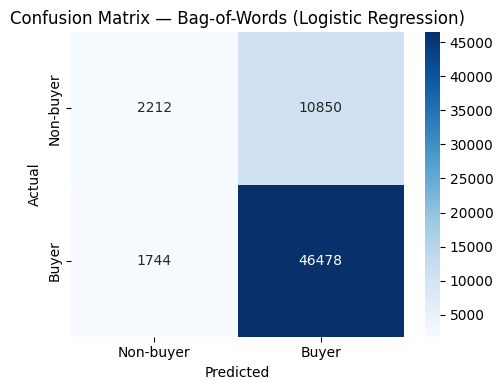

Classification Report — Bag-of-Words (Logistic Regression):
              precision    recall  f1-score   support

   Non-buyer       0.56      0.17      0.26     13062
       Buyer       0.81      0.96      0.88     48222

    accuracy                           0.79     61284
   macro avg       0.68      0.57      0.57     61284
weighted avg       0.76      0.79      0.75     61284



In [13]:
plot_confusion_matrix(labels, bow_preds,
    f'Confusion Matrix — Bag-of-Words ({bow_best})')

print(f'Classification Report — Bag-of-Words ({bow_best}):')
print(classification_report(labels, bow_preds, target_names=['Non-buyer', 'Buyer']))

**Discussion (Q1):**

*Fill in after running. Consider:*
- *Which representation performed best overall, and why?*
- *Did TF-IDF weighted embeddings outperform unweighted ones?*
- *How did Bag-of-Words compare to dense embedding approaches?*
- *Which classifier was most consistent across representations?*

### Q2: Does More Information Improve Accuracy?
Test three scenarios — text only, text + title, text + title + extra features.

In [14]:
# Build Bag of Words for review titles using same vocabulary
df['review_title'] = df['review_title'].fillna('')
t_rows, t_cols, t_vals = [], [], []

for i, title in enumerate(df['review_title'].tolist()):
    wc = {}
    for token in title.lower().split():
        if token in vocab:
            ix = vocab[token]
            wc[ix] = wc.get(ix, 0) + 1
    for ix, fr in wc.items():
        t_rows.append(i); t_cols.append(ix); t_vals.append(fr)

title_bow = csr_matrix((t_vals, (t_rows, t_cols)), shape=(len(df), vocab_size))
del t_rows, t_cols, t_vals

# Encode and scale structured features: brand, product, price, rating
brand_enc   = LabelEncoder().fit_transform(df['brand_name'].fillna('unknown'))
product_enc = LabelEncoder().fit_transform(df['product_title'].fillna('unknown'))
price       = df['price'].fillna(df['price'].median()).values
rating      = df['review_rating'].fillna(df['review_rating'].median()).values
extra       = np.column_stack([brand_enc, product_enc, price, rating]).astype(np.float32)

# Scale to 0-1 range (keeps non-negative for Complement NB)
from sklearn.preprocessing import MinMaxScaler
extra_sparse = csr_matrix(MinMaxScaler().fit_transform(extra))

# Create 3 feature matrices for Q2
text_only_matrix        = bow_matrix
text_title_matrix       = sparse_hstack([bow_matrix, title_bow])
text_title_extra_matrix = sparse_hstack([bow_matrix, title_bow, extra_sparse])

print(f'Scenario 1 — Text Only        : {text_only_matrix.shape}')
print(f'Scenario 2 — Text + Title     : {text_title_matrix.shape}')
print(f'Scenario 3 — Text+Title+Extra : {text_title_extra_matrix.shape}')

Scenario 1 — Text Only        : (61284, 8054)
Scenario 2 — Text + Title     : (61284, 16108)
Scenario 3 — Text+Title+Extra : (61284, 16112)


In [15]:
# All 3 cases use non-negative features (BoW + MinMaxScaler)
# so we can use classifiers_bow which includes Complement NB

#  Case 1: Text only
q2_s1, s1_best, s1_preds = evaluate_full(
    'Q2 — Scenario 1: Text Only',
    text_only_matrix, labels, classifiers_bow, cv)

# Case 2: Text + Title
q2_s2, s2_best, s2_preds = evaluate_full(
    'Q2 — Scenario 2: Text + Title',
    text_title_matrix, labels, classifiers_bow, cv)

# Case 3: Text + Title + Extra Features
q2_s3, s3_best, s3_preds = evaluate_full(
    'Q2 — Scenario 3: Text + Title + Extra Features',
    text_title_extra_matrix, labels, classifiers_bow, cv)


-----------------------------------------------------------------
  Q2 — Scenario 1: Text Only
-----------------------------------------------------------------
Classifier                  Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Logistic Regression           0.7945     0.7571     0.7945     0.7484
Linear SVC                    0.7825     0.7402     0.7825     0.7452
SGD Classifier                0.7905     0.7496     0.7905     0.7458
Complement NB                 0.6581     0.7370     0.6581     0.6845
Random Forest                 0.7883     0.7474     0.7883     0.7475

  Best model: Logistic Regression (F1 = 0.7484)

-----------------------------------------------------------------
  Q2 — Scenario 2: Text + Title
-----------------------------------------------------------------
Classifier                  Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Lo


====== Q2 Summary: Does More Information Improve Accuracy? ======
Scenario                                      Best Model                  Accuracy         F1
-----------------------------------------------------------------------------------------------
1. Text Only                                  Logistic Regression           0.7945     0.7484
2. Text + Title                               Logistic Regression           0.7964     0.7562
3. Text + Title + Extra Features              Random Forest                 0.8225     0.8004


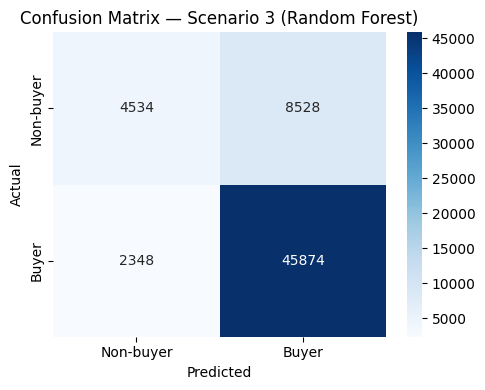


Classification Report — Scenario 3 (Random Forest):
              precision    recall  f1-score   support

   Non-buyer       0.66      0.35      0.45     13062
       Buyer       0.84      0.95      0.89     48222

    accuracy                           0.82     61284
   macro avg       0.75      0.65      0.67     61284
weighted avg       0.80      0.82      0.80     61284



In [16]:
# Summary table + confusion matrix

print('\n====== Q2 Summary: Does More Information Improve Accuracy? ======')
print(f'{"Scenario":<45} {"Best Model":<25} {"Accuracy":>10} {"F1":>10}')
print('-' * 95)
for scen_name, scen_res in [
    ('1. Text Only',                     q2_s1),
    ('2. Text + Title',                  q2_s2),
    ('3. Text + Title + Extra Features', q2_s3)
]:
    best = max(scen_res, key=lambda k: scen_res[k]['f1'])
    r = scen_res[best]
    print(f'{scen_name:<45} {best:<25} {r["accuracy"]:>10.4f} {r["f1"]:>10.4f}')

# Confusion matrix for best scenario (Scenario 3)
plot_confusion_matrix(labels, s3_preds,
    f'Confusion Matrix — Scenario 3 ({s3_best})')

print(f'\nClassification Report — Scenario 3 ({s3_best}):')
print(classification_report(labels, s3_preds, target_names=['Non-buyer', 'Buyer']))

**Discussion (Q2):**

*Fill in after running. Consider:*
- *Did adding review title improve accuracy? By how much?*
- *Did brand, price, rating, and product name further improve accuracy?*
- *Were improvements consistent across all classifiers?*
- *Is there any case where adding more features hurt performance?*

---
## Summary

In **Task 2**, we generated three feature representations from 61,284 preprocessed cosmetics reviews using the 8,054-word vocabulary from Task 1:
- **Bag-of-Words**: sparse count matrix of shape (61284, 8054)
- **Unweighted Word2Vec**: dense 100-dimensional embeddings, mean-averaged per review
- **TF-IDF Weighted Word2Vec**: 100-dimensional embeddings weighted by term importance

In **Task 3**, we used 5-fold stratified cross-validation with up to 4 classifiers to predict `is_a_buyer`. Results are summarised in the tables above.

*Fill in key findings from Q1 and Q2 after running the notebook.*